# Day 20 – ROC, AUC & Multilabel Classification

## Learning Objectives

After completing this notebook, you should be able to:
1. Explain TPR and FPR.
2. Draw and interpret an ROC curve.
3. Interpret AUC values.
4. Decide when a PR curve is more informative than ROC.
5. Train and evaluate multiclass classifiers.
6. Understand OvR and OvO strategies.
7. Build a simple multilabel classifier.

## Import Libraries

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, make_multilabel_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    accuracy_score
)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
import warnings
warnings.filterwarnings('ignore')

---


- Lower threshold → higher recall, lower precision.
- Higher threshold → higher precision, lower recall.

The **PR curve** summarizes this trade-off across all thresholds.

Instead of plotting **Precision vs Recall**, we now plot:

- **True Positive Rate (TPR / Recall)** on the Y-axis
- **False Positive Rate (FPR)** on the X-axis

This new plot is called the **ROC Curve**.

Think of it as:

- **PR curve** → focuses on the positive class.
- **ROC curve** → compares detection of positives against false alarms.

So ROC is not a completely new topic; it is an **extension of the threshold analysis** you already studied on Day 19.

---

# Part 1 – Binary Classification for ROC/AUC

We will use the **Digits** dataset and create a binary problem:
**Is the digit equal to 5?**

In [12]:
digits = load_digits()
X = digits.data
y = digits.target

# Binary target: 5 vs not 5
y_binary = (y == 5)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.25, random_state=42, stratify=y_binary
)

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)

# Decision scores
y_scores = sgd_clf.decision_function(X_test)
y_pred = sgd_clf.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))

Accuracy: 0.9888888888888889

Confusion Matrix:
 [[400   4]
 [  1  45]]


## TPR and FPR

From the confusion matrix:

- **TPR (Recall)** = TP / (TP + FN)
- **FPR** = FP / (FP + TN)

TPR measures how many positive samples are correctly detected.
FPR measures how many negative samples are incorrectly marked positive.

In [13]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

tpr = tp / (tp + fn)
fpr = fp / (fp + tn)

print(f'TPR (Recall): {tpr:.3f}')
print(f'FPR: {fpr:.3f}')

TPR (Recall): 0.978
FPR: 0.010


---

## ROC Curve

The ROC curve plots **TPR vs FPR** for every possible threshold.

- Top-left corner is ideal.
- The diagonal line represents a random classifier.

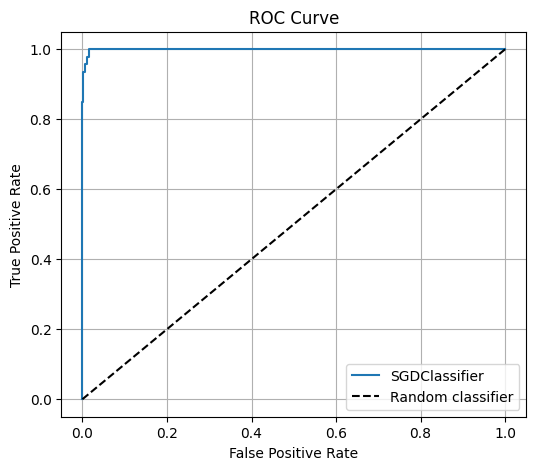

In [14]:
fpr_vals, tpr_vals, thresholds = roc_curve(y_test, y_scores)

plt.figure(figsize=(6, 5))
plt.plot(fpr_vals, tpr_vals, label='SGDClassifier')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

### Interpretation

- A curve closer to the top-left is better.
- Increasing recall usually increases false positives.
- Threshold selection controls this trade-off.

---

## AUC – Area Under the ROC Curve

In [15]:
auc_score = roc_auc_score(y_test, y_scores)
print('ROC AUC Score:', round(auc_score, 4))

ROC AUC Score: 0.9991


### AUC Interpretation

| AUC | Meaning |
|---|---|
| 0.50 | Random guessing |
| 0.60–0.70 | Poor |
| 0.70–0.80 | Fair |
| 0.80–0.90 | Good |
| 0.90–1.00 | Excellent |

**AUC = probability that a random positive sample receives a higher score than a random negative sample.**

---

# Part 2 – Quick Revision from Day 19: Precision–Recall Curve

Before moving to ROC, let us quickly revisit the PR curve you learned in Day 19.

PR curves are often more informative when the positive class is **rare**.

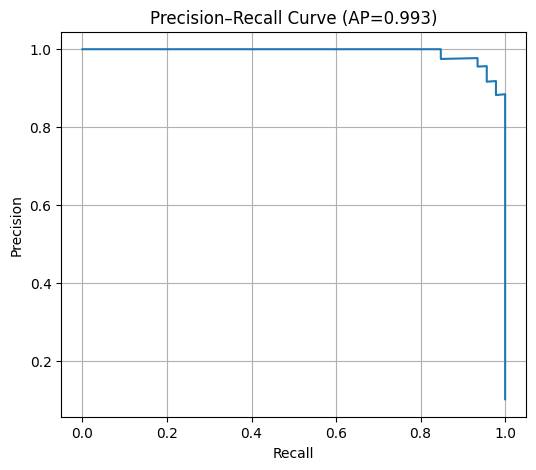

Average Precision: 0.9927


In [16]:
precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_scores)
ap_score = average_precision_score(y_test, y_scores)

plt.figure(figsize=(6, 5))
plt.plot(recalls, precisions)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision–Recall Curve (AP={ap_score:.3f})')
plt.grid(True)
plt.show()

print('Average Precision:', round(ap_score, 4))

### Bridge to ROC

Notice that the PR curve uses **Precision** on the Y-axis.

ROC replaces Precision with **TPR (Recall)** and introduces **FPR** on the X-axis.

Therefore:

- PR asks: *"Among predicted positives, how many are correct?"*
- ROC asks: *"How many positives are found, and how many negatives are wrongly flagged?"*

This is the conceptual transition from Day 19 to Day 20.

## When PR Curves Are Better Than ROC

Use PR curves when:
- Positive class is **very small** (fraud, disease, defects, spam).
- You care more about **finding positives** than negatives.
- False positives are costly.

ROC can appear optimistic on highly imbalanced datasets because true negatives dominate.

---

# Quick Visual Intuition

Move the threshold and observe how TPR and FPR change.

<InferenceRegressionMl type_id="ROC_CURVE"/>

---

# Part 3 – Multiclass Classification

The original Digits dataset has **10 classes (0–9)**.

In [17]:
X_train_mc, X_test_mc, y_train_mc, y_test_mc = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

ovr_clf = OneVsRestClassifier(LogisticRegression(max_iter=5000))
ovr_clf.fit(X_train_mc, y_train_mc)

y_pred_mc = ovr_clf.predict(X_test_mc)

print('Multiclass Accuracy:', accuracy_score(y_test_mc, y_pred_mc))

Multiclass Accuracy: 0.96


## Classification Report

In [18]:
print(classification_report(y_test_mc, y_pred_mc))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        45
           1       0.95      0.87      0.91        46
           2       1.00      0.98      0.99        44
           3       0.96      0.98      0.97        46
           4       0.96      1.00      0.98        45
           5       0.98      0.98      0.98        46
           6       0.98      0.98      0.98        45
           7       0.96      0.98      0.97        45
           8       0.85      0.95      0.90        43
           9       0.98      0.91      0.94        45

    accuracy                           0.96       450
   macro avg       0.96      0.96      0.96       450
weighted avg       0.96      0.96      0.96       450



---

## One-vs-Rest (OvR)

For **K classes**, train **K binary classifiers**.

Example with digits:
- Classifier 0: 0 vs others
- Classifier 1: 1 vs others
- ...
- Classifier 9: 9 vs others

The class with the **highest score wins**.

## One-vs-One (OvO)

Train a classifier for **every pair of classes**.

Number of classifiers:

**K × (K − 1) / 2**

For 10 classes:

**10 × 9 / 2 = 45 classifiers**

### OvR vs OvO

| Strategy | # Classifiers | Good For |
|---|---|---|
| OvR | K | Large datasets |
| OvO | K(K−1)/2 | Algorithms that train fast on small subsets |

Scikit-learn automatically chooses a suitable strategy for many estimators.

---

# Part 4 – Multiclass ROC AUC

ROC AUC can be extended to multiclass problems using **OvR** averaging.

In [19]:
y_proba = ovr_clf.predict_proba(X_test_mc)

multiclass_auc = roc_auc_score(
    y_test_mc,
    y_proba,
    multi_class='ovr',
    average='macro'
)

print('Multiclass ROC AUC (OvR, macro):', round(multiclass_auc, 4))

Multiclass ROC AUC (OvR, macro): 0.998


### Averaging Methods

- **macro**: average all classes equally.
- **weighted**: weighted by class frequency.
- **micro**: aggregate all decisions together.

---

# Part 5 – Multilabel Classification

In multilabel classification, a sample can belong to **multiple labels simultaneously**.

Example: a photo may contain **dog**, **car**, and **tree**.

In [20]:
X_ml, Y_ml = make_multilabel_classification(
    n_samples=1000,
    n_features=20,
    n_classes=3,
    n_labels=2,
    random_state=42
)

X_train_ml, X_test_ml, Y_train_ml, Y_test_ml = train_test_split(
    X_ml, Y_ml, test_size=0.25, random_state=42
)

forest = RandomForestClassifier(random_state=42)
multi_clf = MultiOutputClassifier(forest)
multi_clf.fit(X_train_ml, Y_train_ml)

Y_pred_ml = multi_clf.predict(X_test_ml)

print('First 5 true labels:\n', Y_test_ml[:5])
print('\nFirst 5 predicted labels:\n', Y_pred_ml[:5])

First 5 true labels:
 [[1 1 1]
 [1 0 0]
 [0 1 0]
 [1 1 1]
 [0 0 0]]

First 5 predicted labels:
 [[1 1 1]
 [1 0 0]
 [0 1 0]
 [1 1 1]
 [0 1 1]]


### What Happened?

- Each sample has a vector like `[1, 0, 1]`.
- The model predicts each label independently.
- This is different from multiclass classification where exactly one class is chosen.